# 02. Weighted CNN Baseline for Melanoma Classification

**Objective**  
Extend the plain CNN baseline by introducing class weighting in `BCEWithLogitsLoss` so that melanoma mistakes are penalized more heavily during training. This notebook tests whether a weighted loss improves minority-class detection without changing the underlying CNN architecture.

**Model Architecture**

| Stage | Layers |
| --- | --- |
| Input | RGB dermoscopic image |
| Block 1 | `Conv2d -> ReLU -> MaxPool2d` |
| Block 2 | `Conv2d -> ReLU -> MaxPool2d` |
| Block 3 | `Conv2d -> ReLU -> MaxPool2d` |
| Classifier | `Flatten -> Linear(128 x 28 x 28, 256) -> ReLU -> Dropout -> Linear(256, 1)` |

**Hypothesis**  
Compared with the unweighted baseline, adding `pos_weight` should increase melanoma recall and improve recall-focused metrics such as F2 and balanced accuracy. The trade-off is that precision and overall accuracy may decrease because the model becomes more willing to predict melanoma.


### 1. Setup and Imports

This section loads the project modules, trainer utilities, and shared evaluation helpers, then selects the available compute device (`CUDA`, `MPS`, or `CPU`).


In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from src.data.dataloader import get_dataloaders
from src.models.cnn_baseline import SimpleCNN
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: mps


### 2. Data Split and Weighted-Loss Configuration

The dataset is loaded using the predefined train, validation, and test CSV splits.  
This experiment keeps the same `SimpleCNN` architecture as Notebook 01, but changes the loss from unweighted BCE to weighted BCE:

- `SimpleCNN` as the feature extractor and classifier
- `BCEWithLogitsLoss(pos_weight=...)` to penalize missed melanoma more strongly
- `Adam` with learning rate `1e-3`
- Batch size `32` and image size `224 x 224`

The positive-class weight is computed as:

`pos_weight = number_of_nevus / number_of_melanoma`

This makes melanoma errors contribute more to the training loss because melanoma is the minority class.


In [2]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / "data_new/splits/train.csv"),
    val_csv=str(ROOT / "data_new/splits/val.csv"),
    test_csv=str(ROOT / "data_new/splits/test.csv"),
    image_dir=str(ROOT / "data_new/images/train"),
    test_image_dir=str(ROOT / "data_new/images/test"),
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv(ROOT / "data_new/splits/train.csv")

num_melanoma = (train_df["label"] == 1).sum()
num_nevus = (train_df["label"] == 0).sum()

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32, device=device)

print(f"Melanoma samples: {num_melanoma}")
print(f"Nevus samples: {num_nevus}")
print(f"pos_weight: {pos_weight.item():.4f}")

model = SimpleCNN().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

best_model_path = ROOT / "models/cnn_baseline_weighted_best.pth"
best_model_path.parent.mkdir(parents=True, exist_ok=True)


Melanoma samples: 877
Nevus samples: 7114
pos_weight: 8.1117


### 3. Train the Weighted Baseline Model

The model is trained for `20` epochs using the same CNN as Notebook 01, but with weighted BCE loss. Training and validation metrics are stored as lists of dictionaries so they can be passed directly into the shared plotting function later. The checkpoint with the lowest validation loss is saved.


In [ ]:
best_val_loss = float("inf")
num_epochs = 20

train_history = []
val_history = []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Train Bal Acc: {train_metrics['balanced_accuracy']:.4f} | "
        f"Train Recall: {train_metrics['recall']:.4f} | "
        f"Train F2: {train_metrics['f2']:.4f} || "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Bal Acc: {val_metrics['balanced_accuracy']:.4f} | "
        f"Val Recall: {val_metrics['recall']:.4f} | "
        f"Val F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        torch.save(model.state_dict(), best_model_path)
        print(f"Saved best model to: {best_model_path}")


Epoch 01/20 | Train Loss: 1.2589 | Train Bal Acc: 0.5952 | Train Recall: 0.4652 | Train F2: 0.3475 || Val Loss: 1.1132 | Val Bal Acc: 0.6966 | Val Recall: 0.6907 | Val F2: 0.4973
Saved best model to: /Users/joelyeo/Desktop/Deep Learning/Project/50.039-Deep-Learning/models/cnn_baseline_weighted_best.pth


Epoch 02/20 | Train Loss: 1.0207 | Train Bal Acc: 0.7166 | Train Recall: 0.8267 | Train F2: 0.5155 || Val Loss: 0.9570 | Val Bal Acc: 0.7336 | Val Recall: 0.8475 | Val F2: 0.5482
Saved best model to: /Users/joelyeo/Desktop/Deep Learning/Project/50.039-Deep-Learning/models/cnn_baseline_weighted_best.pth


Epoch 03/20 | Train Loss: 0.9697 | Train Bal Acc: 0.7275 | Train Recall: 0.8518 | Train F2: 0.5277 || Val Loss: 0.9374 | Val Bal Acc: 0.7507 | Val Recall: 0.8941 | Val F2: 0.5681
Saved best model to: /Users/joelyeo/Desktop/Deep Learning/Project/50.039-Deep-Learning/models/cnn_baseline_weighted_best.pth


Epoch 04/20 | Train Loss: 0.9508 | Train Bal Acc: 0.7442 | Train Recall: 0.8620 | Train F2: 0.5461 || Val Loss: 0.9102 | Val Bal Acc: 0.7579 | Val Recall: 0.9068 | Val F2: 0.5762
Saved best model to: /Users/joelyeo/Desktop/Deep Learning/Project/50.039-Deep-Learning/models/cnn_baseline_weighted_best.pth


Epoch 05/20 | Train Loss: 0.8945 | Train Bal Acc: 0.7546 | Train Recall: 0.8518 | Train F2: 0.5581 || Val Loss: 0.8852 | Val Bal Acc: 0.7598 | Val Recall: 0.9195 | Val F2: 0.5784
Saved best model to: /Users/joelyeo/Desktop/Deep Learning/Project/50.039-Deep-Learning/models/cnn_baseline_weighted_best.pth


...

Epoch 16/20 | Train Loss: 0.7884 | Train Bal Acc: 0.7929 | Train Recall: 0.8860 | Train F2: 0.6050 || Val Loss: 0.8430 | Val Bal Acc: 0.7743 | Val Recall: 0.9110 | Val F2: 0.5949


Epoch 17/20 | Train Loss: 0.7454 | Train Bal Acc: 0.7965 | Train Recall: 0.8746 | Train F2: 0.6109 || Val Loss: 0.8467 | Val Bal Acc: 0.7697 | Val Recall: 0.8263 | Val F2: 0.5902


Epoch 18/20 | Train Loss: 0.7378 | Train Bal Acc: 0.8020 | Train Recall: 0.8769 | Train F2: 0.6184 || Val Loss: 1.0124 | Val Bal Acc: 0.7476 | Val Recall: 0.8051 | Val F2: 0.5628


Epoch 19/20 | Train Loss: 0.7273 | Train Bal Acc: 0.8025 | Train Recall: 0.8723 | Train F2: 0.6194 || Val Loss: 0.8367 | Val Bal Acc: 0.7793 | Val Recall: 0.8729 | Val F2: 0.6016


Epoch 20/20 | Train Loss: 0.7297 | Train Bal Acc: 0.8056 | Train Recall: 0.8746 | Train F2: 0.6237 || Val Loss: 0.9014 | Val Bal Acc: 0.7668 | Val Recall: 0.8008 | Val F2: 0.5866


### 4. Plot Training Curves

This notebook uses the shared evaluation utility to render the standard 2 × 2 dashboard: Loss, Balanced Accuracy, Recall, and F2. This keeps the weighted experiment directly comparable with Notebook 01.


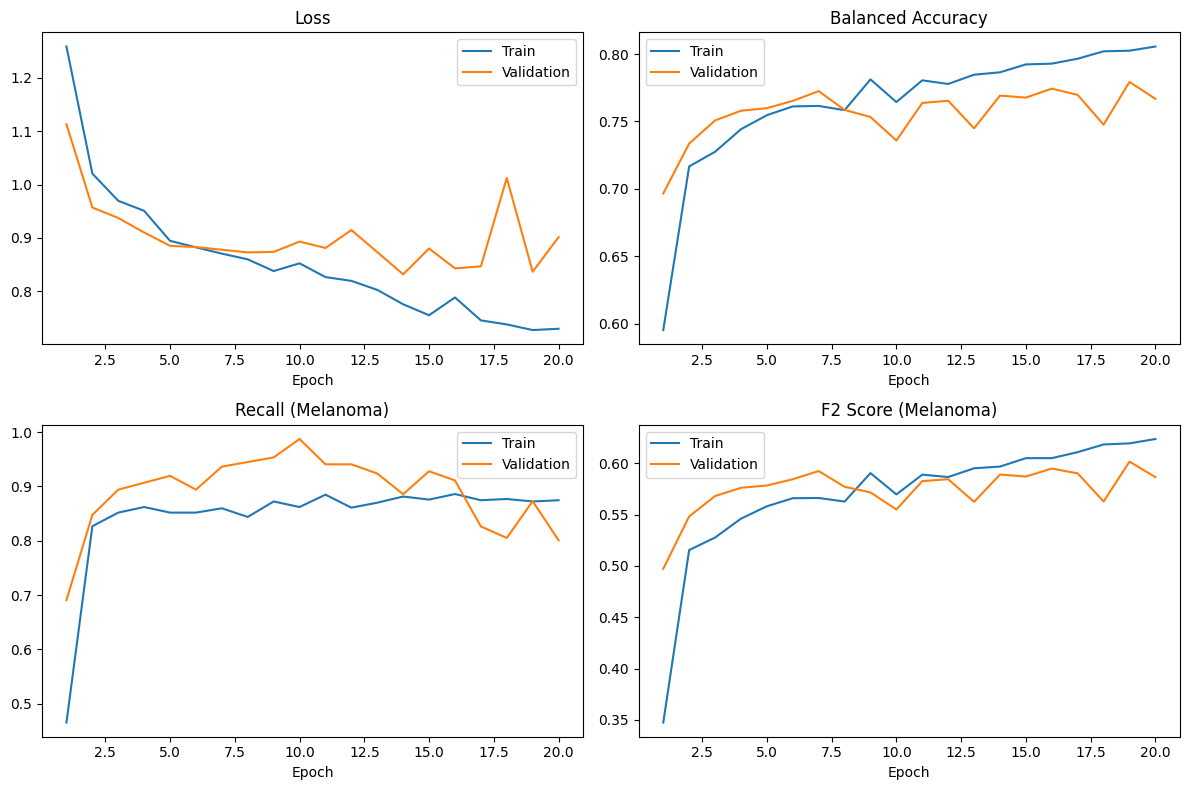

In [4]:
plot_training_curves(train_history, val_history)

### 5. Tune the Classification Threshold on the Validation Set

The loss is weighted during training, but the classification threshold still needs to be chosen separately.  
This step reloads the best saved checkpoint and finds the probability threshold that maximizes **F2 score** on the validation set.


In [5]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

print(f"Best validation threshold: {best_threshold:.2f}")
print(f"Best validation F2: {best_f2:.4f}")

Best threshold: 0.53 | Val F2: 0.5958
Best validation threshold: 0.53
Best validation F2: 0.5958


### 6. Evaluate on the Test Set

The best weighted checkpoint is evaluated on the held-out test set using the threshold selected on the validation set.  
The shared evaluation utility reports AUC-ROC, balanced accuracy, F2 score, a classification report, and visual diagnostics such as the confusion matrix and ROC curve.


Threshold:          0.53
AUC-ROC:            0.8539
Balanced Accuracy:  0.7697
F2 Score:           0.5831

              precision    recall  f1-score   support

Non-Melanoma     0.9752    0.6739    0.7970      1340
    Melanoma     0.2530    0.8655    0.3915       171

    accuracy                         0.6956      1511
   macro avg     0.6141    0.7697    0.5943      1511
weighted avg     0.8934    0.6956    0.7511      1511



/Users/joelyeo/Desktop/Deep Learning/Project/50.039-Deep-Learning/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


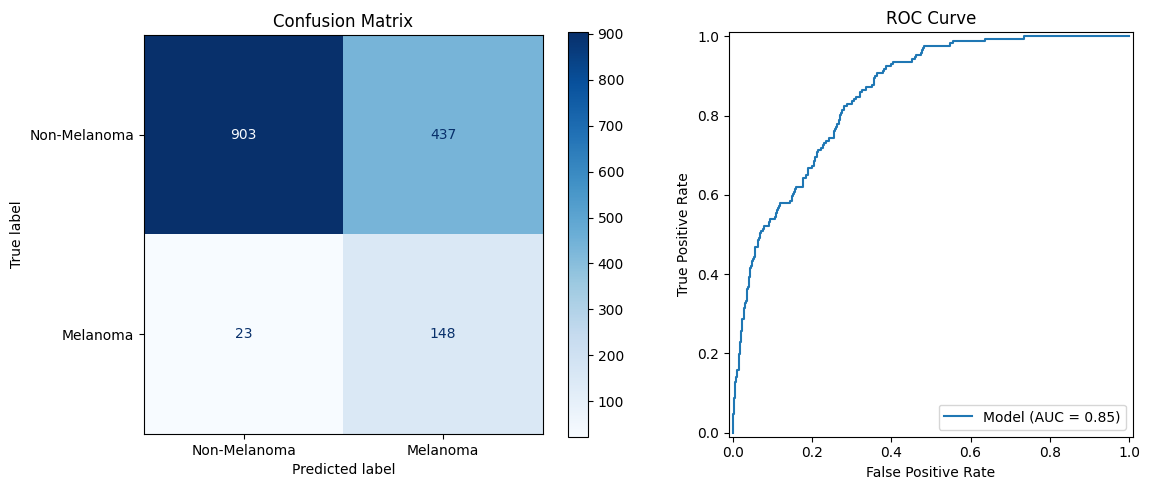

In [6]:
evaluate_model(model, test_loader, device, threshold=best_threshold)

### 7. Weighted Baseline Interpretation

This notebook isolates the effect of **class weighting** while keeping the CNN architecture unchanged.  
When compared with Notebook 01, the key question is whether the weighted loss improves **melanoma recall** and **F2 score** enough to justify any drop in precision or overall accuracy.

In medical screening, a weighted model is often preferable if it misses substantially fewer melanoma cases, even when it produces more false positives.
